# Setting up enviroment + helper function

In [1]:
# Cell 1 — imports + robust price selector
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)

def select_price_frame(df, prefer="Adj Close"):
    if df is None or len(df) == 0:
        raise ValueError("Downloaded data is empty.")

    # If it's a Series (single ticker), turn into DataFrame
    if isinstance(df, pd.Series):
        return df.to_frame(df.name)

    # If multi-index columns, find which level has field names
    if isinstance(df.columns, pd.MultiIndex):
        fields = {"Adj Close", "Close", "Close*"}
        field_level = None
        for lvl in range(df.columns.nlevels):
            names = set(df.columns.get_level_values(lvl))
            if fields & names:
                field_level = lvl
                break
        if field_level is None:
            # Some rare cases: auto_adjust=True => no 'Adj Close' exists, use 'Close'
            # Try to collapse to a wide matrix of 'Close' if present
            for candidate in ("Close", "Adj Close"):
                try:
                    prices = df.xs(candidate, level=field_level, axis=1)
                    return prices
                except Exception:
                    pass
            # As a last resort, if only one field level exists per ticker, try last level
            # and assume they are closes
            return df.droplevel(list(range(df.columns.nlevels-1)), axis=1)

        # Prefer Adj Close, else Close
        target = "Adj Close" if "Adj Close" in set(df.columns.get_level_values(field_level)) else "Close"
        prices = df.xs(target, level=field_level, axis=1)
        # Ensure columns are just tickers
        if isinstance(prices.columns, pd.MultiIndex):
            prices.columns = prices.columns.get_level_values(0)
        return prices

    # Single-index columns: try 'Adj Close' or 'Close'
    cols = df.columns.astype(str)
    if "Adj Close" in cols:
        series = df["Adj Close"]
        return series.to_frame(series.name if series.name else "Adj Close")
    if "Close" in cols:
        series = df["Close"]
        return series.to_frame(series.name if series.name else "Close")

    # If the frame already looks like tickers across columns (one column per ticker), return as is
    return df


# Downloading and Preparing Data

In [2]:
# Cell 2 — download prices
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN"]

# download full table, then select prices with our helper
raw = yf.download(tickers, start="2020-01-01", end="2024-01-01", progress=False)
prices = select_price_frame(raw)  # prefers Adj Close, else Close

prices = prices.dropna(how="all")
prices.tail()


C:\Users\mar_c\AppData\Local\Temp\ipykernel_26580\779999331.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(tickers, start="2020-01-01", end="2024-01-01", progress=False)


Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2023-12-22,191.788757,153.419998,140.428986,369.077118
2023-12-26,191.243896,153.410004,140.458725,369.155914
2023-12-27,191.342957,153.339996,139.317352,368.574646
2023-12-28,191.768936,153.380005,139.178406,369.766785
2023-12-29,190.728760,151.940002,138.642471,370.515686


# Calculating Returns and Annualised Stats

In [4]:
# Cell 3 — returns and annualized stats
returns = prices.pct_change().dropna()
mu_ann = returns.mean() * 252
cov_ann = returns.cov() * 252

mu_ann, cov_ann.shape


(Ticker
 AAPL     0.299015
 AMZN     0.188953
 GOOGL    0.235248
 MSFT     0.275846
 dtype: float64,
 (4, 4))

# Markowitz Optimisation Functions

In [18]:
# Cell 4 — portfolio math + optimizer
def portfolio_perf(weights, mu, cov):
    """
    Annualized risk and return for a weight vector.
    """
    port_ret = float(np.dot(weights, mu))
    port_vol = float(np.sqrt(np.dot(weights, cov @ weights)))
    return port_vol, port_ret

def min_vol_for_target(mu, cov, target_return, bounds=(0.0, 1.0)):
    """
    Minimize volatility subject to:
      - sum(weights) = 1
      - expected return = target_return
      - bounds on each weight
    """
    n = len(mu)
    x0 = np.full(n, 1.0 / n)
    cons = (
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},
        {"type": "eq", "fun": lambda w: np.dot(w, mu) - target_return},
    )
    bnds = tuple((bounds[0], bounds[1]) for _ in range(n))
    res = minimize(lambda w: portfolio_perf(w, mu, cov)[0], x0, method="SLSQP",
                   bounds=bnds, constraints=cons, options={"maxiter": 1000})
    if not res.success:
        raise RuntimeError(f"Optimizer failed: {res.message}")
    return res.x


# Running the Optimisation

In [6]:
# Cell 5 — example optimization
target = float(mu_ann.mean())  # e.g., target as average expected return
w_opt = min_vol_for_target(mu_ann.values, cov_ann.values, target_return=target)

risk, ret = portfolio_perf(w_opt, mu_ann.values, cov_ann.values)
weights = pd.Series(w_opt, index=mu_ann.index).round(4)

print("Optimal weights:")
print(weights)
print(f"\nAnnualized return: {ret:.2%}")
print(f"Annualized volatility: {risk:.2%}")


Optimal weights:
Ticker
AAPL     0.2285
AMZN     0.2094
GOOGL    0.3246
MSFT     0.2375
dtype: float64

Annualized return: 24.98%
Annualized volatility: 30.17%


# Plotting the Efficient Frontier

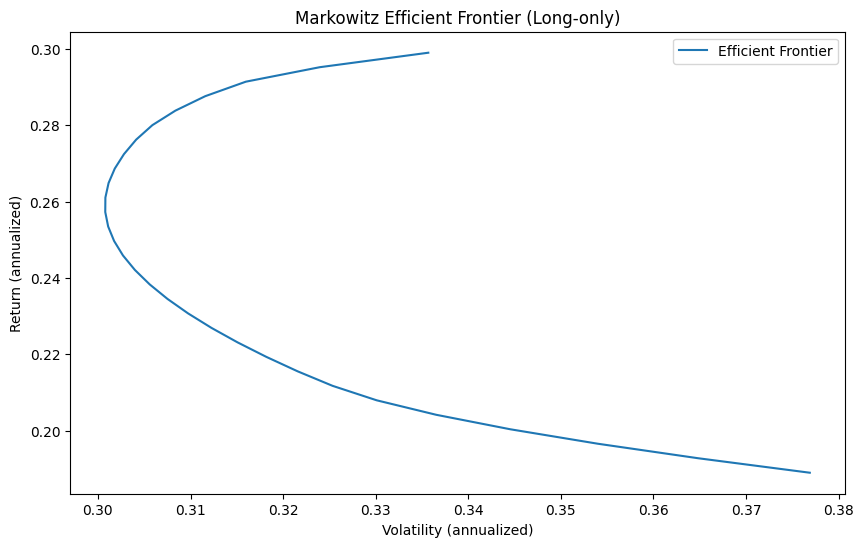

In [7]:
# Cell 6 — efficient frontier
targets = np.linspace(mu_ann.min(), mu_ann.max(), 30)
risks, rets = [], []

for t in targets:
    try:
        w = min_vol_for_target(mu_ann.values, cov_ann.values, target_return=float(t))
        r, R = portfolio_perf(w, mu_ann.values, cov_ann.values)
        risks.append(r); rets.append(R)
    except Exception:
        # some targets might be infeasible with long-only bounds
        pass

plt.plot(risks, rets, label="Efficient Frontier")
plt.xlabel("Volatility (annualized)")
plt.ylabel("Return (annualized)")
plt.legend()
plt.title("Markowitz Efficient Frontier (Long-only)")
plt.show()


# AI‑Enhanced Markowitz

# Imports for Machine Learning Models

In [ ]:
# Cell A — extra imports for ML
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import TimeSeriesSplit
np.random.seed(42) # for reproducibility


# Build Machine Learning Features

In [ ]:
# Este bloque construye features temporales sin leakage para cada activo y define como objetivo predecir el retorno promedio del próximo mes (21 días), preparando los datos para un modelo ML que alimente Markowitz.

# Copia de los retornos diarios (DataFrame: filas = fechas, columnas = activos)
daily_ret = returns.copy()

# DataFrame base para features (se usará el índice temporal)
feat = pd.DataFrame(index=daily_ret.index)

# ------------------------------------------------------------
# Función para crear features de UN activo
# Todas las features usan shift(1) para evitar leakage
# ------------------------------------------------------------
def add_asset_features(r):
    out = pd.DataFrame(index=r.index)

    # Retorno de ayer (t-1)
    out["ret_1"]  = r.shift(1)

    # Retorno promedio de los últimos 5 días (hasta ayer)
    out["ret_5"]  = r.rolling(5).mean().shift(1)

    # Retorno promedio de los últimos 21 días (~1 mes, hasta ayer)
    out["ret_21"] = r.rolling(21).mean().shift(1)

    # Volatilidad de 21 días (desviación estándar, hasta ayer)
    out["vol_21"] = r.rolling(21).std().shift(1)

    # Momentum de 63 días (~3 meses):
    # producto acumulado de (1+r) menos 1, hasta ayer
    out["mom_63"] = (
        (1 + r)
        .rolling(63)
        .apply(lambda x: np.prod(x) - 1, raw=False)
        .shift(1)
    )

    return out

# ------------------------------------------------------------
# Construcción de la matriz de features "wide"
# Cada activo aporta sus propias columnas con prefijo
# ------------------------------------------------------------
X_list = []
for t in daily_ret.columns:
    # Calcula features para el activo t
    f = add_asset_features(daily_ret[t])

    # Agrega prefijo con el ticker para distinguir columnas
    f = f.add_prefix(f"{t}_")

    X_list.append(f)

# Concatena todas las features de todos los activos en un solo DataFrame
X = pd.concat(X_list, axis=1)

# ------------------------------------------------------------
# Variable objetivo (label)
# Retorno promedio FORWARD de los próximos 21 días por activo
# ------------------------------------------------------------
y = daily_ret.rolling(21).mean().shift(-21)

# ------------------------------------------------------------
# Alineación final y limpieza
# ------------------------------------------------------------

# Une features (X) y targets (y) usando solo fechas comunes
XY = X.join(y, how="inner", lsuffix="", rsuffix="")

# Elimina filas con NaNs (por ventanas rolling y shifts)
XY = XY.dropna()

# Separa de nuevo X (features) y y (targets)
X = XY[X.columns]
y = XY[y.columns]

# Dimensiones finales del dataset listo para ML
X.shape, y.shape



((921, 20), (921, 4))

# Train a Random Forest for Each Asset

In [ ]:
# Este bloque entrena un modelo de machine learning (Random Forest) por cada activo usando validación temporal, evalúa su estabilidad con R² y guarda el modelo final para predecir retornos esperados forward.

# Diccionario para guardar modelos entrenados por ticker
models = {}

# Diccionario para guardar el desempeño promedio (R²) por ticker
scores = {}

# TimeSeriesSplit:
# - divide los datos respetando el orden temporal
# - evita mezclar pasado con futuro
tscv = TimeSeriesSplit(n_splits=5)

# Iteramos sobre cada activo (cada columna del target y)
for t in y.columns:
    # Target específico del activo t:
    # retorno promedio forward a 21 días
    y_t = y[t]

    # Definición del modelo:
    # Random Forest robusto a no linealidades y ruido
    rf = RandomForestRegressor(
        n_estimators=400,      # número de árboles (más árboles = más estabilidad)
        max_depth=None,        # árboles sin profundidad fija
        random_state=42,       # reproducibilidad
        n_jobs=-1              # usa todos los cores disponibles
    )

    # Lista para guardar el R² de cada fold temporal
    fold_scores = []

    # Validación cruzada tipo rolling / expanding window
    for train_idx, test_idx in tscv.split(X):
        # Entrena con datos pasados
        rf.fit(X.iloc[train_idx], y_t.iloc[train_idx])

        # Predice en el bloque temporal siguiente
        pred = rf.predict(X.iloc[test_idx])

        # Calcula R² como medida de poder explicativo
        fold_scores.append(
            r2_score(y_t.iloc[test_idx], pred)
        )

    # Promedio del R² en los 5 folds
    # Sirve para evaluar si el modelo tiene señal o es puro ruido
    scores[t] = np.mean(fold_scores)

    # Entrena el modelo FINAL usando todo el dataset disponible
    # (se usará luego para predicciones reales)
    rf.fit(X, y_t)

    # Guarda el modelo entrenado para el activo t
    models[t] = rf

# scores contiene el R² promedio por activo, el tener valores negativos indica que el modelo no logra capturar señal útil ya que deberian ser mayores a 0
scores


{'AAPL': np.float64(-1.0872972769524236),
 'AMZN': np.float64(-0.8618726150700932),
 'GOOGL': np.float64(-0.524902975126114),
 'MSFT': np.float64(-0.4887297300038599)}

# Generate AI Forecasts

In [ ]:

# ------------------------------------------------------------
# Toma la última fila de features disponible
# (representa el "estado actual" del mercado)
# Se usa doble corchete para mantener formato DataFrame
# ------------------------------------------------------------
x_latest = X.iloc[[-1]]

# Lista para almacenar las predicciones de cada activo
pred_vec = []

# ------------------------------------------------------------
# Itera sobre cada activo (cada columna del target y)
# y usa el modelo entrenado para predecir el retorno futuro
# ------------------------------------------------------------
for t in y.columns:
    # models[t] es el RandomForest entrenado para el activo t
    # predict(x_latest) devuelve un array con una sola predicción
    pred_vec.append(models[t].predict(x_latest)[0])

# ------------------------------------------------------------
# Construye una Serie con:
# - índice = tickers
# - valores = retorno promedio esperado a 21 días
# ------------------------------------------------------------
pred_ai = pd.Series(
    pred_vec,
    index=y.columns,
    name="E[next_21d_avg_return]"
)

# Muestra el vector final de retornos esperados "AI"
pred_ai



AAPL     0.001476
AMZN     0.001308
GOOGL    0.001367
MSFT    -0.000255
Name: E[next_21d_avg_return], dtype: float64

# Convert Forecasts to Annualized Expected Returns

In [21]:

# 1) Anualizar los retornos esperados
# pred_ai está en retorno promedio diario esperado
# Multiplicar por 252 aproxima el retorno anual esperado
# ------------------------------------------------------------
mu_ai_ann = (pred_ai * 252)

# ------------------------------------------------------------
# 2) Shrinkage (regularización suave)
# Reduce valores extremos acercándolos al promedio transversal
# Esto evita que el optimizador se vaya a pesos extremos
# ------------------------------------------------------------
shrink_alpha = 0.5                 # 0.5 = 50% señal AI, 50% promedio
mu_bar = mu_ai_ann.mean()          # promedio entre activos

# Combina señal individual con el promedio del portafolio
mu_ai_ann = shrink_alpha * mu_ai_ann + (1 - shrink_alpha) * mu_bar

# ------------------------------------------------------------
# 3) Cap (recorte) de valores extremos
# Limita retornos esperados a un rango razonable
# usando percentiles del retorno histórico anual
# ------------------------------------------------------------
mu_ai_ann = mu_ai_ann.clip(
    lower=mu_ann.quantile(0.05),   # piso (5%)
    upper=mu_ann.quantile(0.95)    # techo (95%)
)

# Retornos esperados finales, listos para usarse en Markowitz
mu_ai_ann


AAPL     0.295540
AMZN     0.287589
GOOGL    0.294919
MSFT     0.195897
Name: E[next_21d_avg_return], dtype: float64

# Optimise Portfolio with AI Forecasts

In [ ]:
# -------------------------------------------------------------------
# 1) Definir un retorno objetivo (target return)
# Aquí se toma como objetivo el promedio de los retornos esperados AI
# (una forma simple de fijar un target razonable)
# -------------------------------------------------------------------
target_ai = float(mu_ai_ann.mean())

# -------------------------------------------------------------------
# 2) Optimización Markowitz: mínima volatilidad sujeto a retorno objetivo
# min_vol_for_target(...) debe resolver algo equivalente a:
#   minimizar:    wᵀ Σ w
#   sujeto a:     wᵀ μ >= target_return
#                sum(w) = 1
#                (y posiblemente bounds/no-short)
#
# Entradas:
# - mu_ai_ann.values  : retornos esperados anualizados (vector μ)
# - cov_ann.values    : covarianza anualizada (matriz Σ)
# - target_return     : retorno mínimo requerido
# Salida:
# - w_ai              : pesos óptimos del portafolio
# -------------------------------------------------------------------
w_ai = min_vol_for_target(
    mu_ai_ann.values,
    cov_ann.values,
    target_return=target_ai
)

# -------------------------------------------------------------------
# 3) Evaluar desempeño del portafolio resultante
# portfolio_perf(...) típicamente devuelve (riesgo, retorno) anualizados
# -------------------------------------------------------------------
risk_ai, ret_ai = portfolio_perf(
    w_ai,
    mu_ai_ann.values,
    cov_ann.values
)

# -------------------------------------------------------------------
# 4) Convertir el vector de pesos a una Serie con nombres de activos
# y redondear para imprimir bonito
# -------------------------------------------------------------------
weights_ai = pd.Series(w_ai, index=mu_ai_ann.index).round(4)

# -------------------------------------------------------------------
# 5) Mostrar resultados
# - pesos por activo
# - retorno anual esperado
# - volatilidad anual esperada
# -------------------------------------------------------------------
print("AI-enhanced optimal weights:")
print(weights_ai)
print(f"\nAI Annualized return: {ret_ai:.2%}")
print(f"AI Annualized volatility: {risk_ai:.2%}")


AI-enhanced optimal weights:
AAPL     0.3094
AMZN     0.1420
GOOGL    0.2902
MSFT     0.2584
dtype: float64

AI Annualized return: 26.85%
AI Annualized volatility: 30.08%


# Compare Traditional vs AI-Enhanced Efficient Frontiers

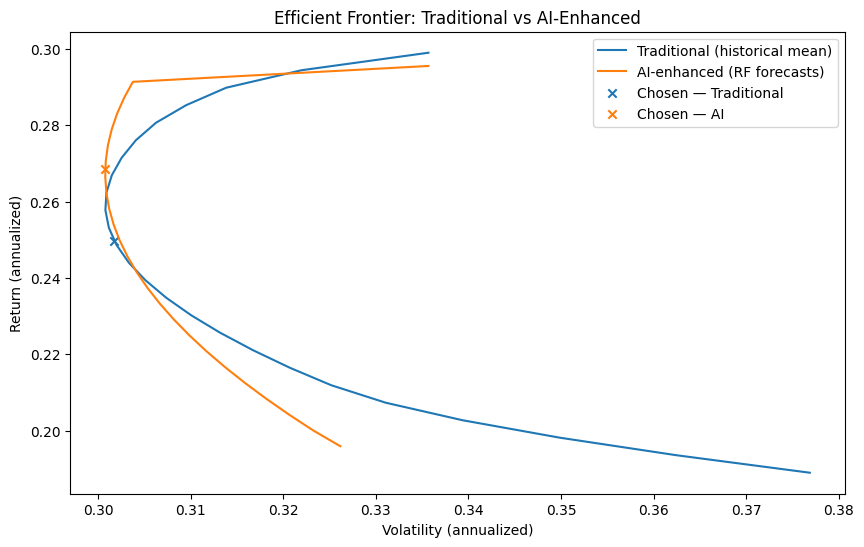

In [14]:
# Cell G — compare frontiers: historical-mean vs AI-forecast
targets_hist = np.linspace(mu_ann.min(), mu_ann.max(), 25)
risks_hist, rets_hist = [], []
for t in targets_hist:
    try:
        w = min_vol_for_target(mu_ann.values, cov_ann.values, float(t))
        r, R = portfolio_perf(w, mu_ann.values, cov_ann.values)
        risks_hist.append(r); rets_hist.append(R)
    except Exception:
        pass

targets_ai = np.linspace(mu_ai_ann.min(), mu_ai_ann.max(), 25)
risks_ai, rets_ai = [], []
for t in targets_ai:
    try:
        w = min_vol_for_target(mu_ai_ann.values, cov_ann.values, float(t))
        r, R = portfolio_perf(w, mu_ai_ann.values, cov_ann.values)
        risks_ai.append(r); rets_ai.append(R)
    except Exception:
        pass

plt.figure(figsize=(10,6))
plt.plot(risks_hist, rets_hist, label="Traditional (historical mean)")
plt.plot(risks_ai, rets_ai, label="AI-enhanced (RF forecasts)")
plt.scatter([risk],[ret], marker="x", label="Chosen — Traditional")
plt.scatter([risk_ai],[ret_ai], marker="x", label="Chosen — AI")
plt.xlabel("Volatility (annualized)")
plt.ylabel("Return (annualized)")
plt.title("Efficient Frontier: Traditional vs AI‑Enhanced")
plt.legend()
plt.show()
